# Netflix Movies & TV Shows — Exploratory Data Analysis

Exploratory Data Analysis (EDA) on Netflix's public content catalog to uncover trends in genre popularity, content additions over time, and country-wise distribution of titles.

**Dataset:** Netflix Movies and TV Shows (originally published on Kaggle, distributed via [TidyTuesday](https://github.com/rfordatascience/tidytuesday/blob/main/data/2021/2021-04-20/readme.md))


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.facecolor'] = '#1b1b1b'
plt.rcParams['axes.facecolor'] = '#1b1b1b'
plt.rcParams['savefig.facecolor'] = '#1b1b1b'
plt.rcParams['text.color'] = '#eaeaea'
plt.rcParams['axes.labelcolor'] = '#eaeaea'
plt.rcParams['xtick.color'] = '#cccccc'
plt.rcParams['ytick.color'] = '#cccccc'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['grid.color'] = '#333333'

df = pd.read_csv("netflix_titles.csv")
df.shape

(7787, 12)

In [2]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 730.2 KB


In [4]:
df.isna().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

## 2. Data Cleaning

- Fill missing `director`, `cast`, `country` with `"Unknown"` rather than dropping rows (dropping would lose most of the dataset, since ~30% of titles are missing at least one of these).
- Drop the small number of rows missing `date_added` or `rating` (under 1% of rows combined).
- Parse `date_added` into a real datetime, and engineer `year_added` / `month_added` for time-based analysis.

In [5]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df = df.dropna(subset=['date_added', 'rating'])

df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='mixed')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

df.shape

(7770, 14)

## 3. Movies vs TV Shows

The catalog skews heavily toward movies.

type
Movie      69.1
TV Show    30.9
Name: count, dtype: float64


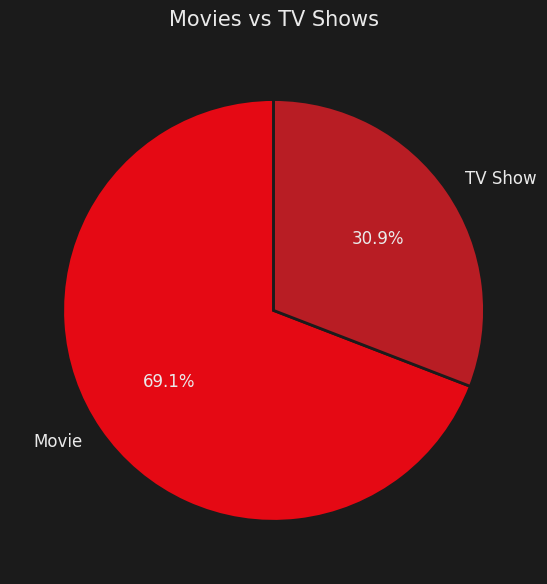

In [6]:
type_counts = df['type'].value_counts()
type_pct = (type_counts / type_counts.sum() * 100).round(1)
print(type_pct)

fig, ax = plt.subplots(figsize=(6,6))
colors = ['#E50914', '#B81D24']
ax.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=colors,
       startangle=90, textprops={'color':'#eaeaea', 'fontsize':12},
       wedgeprops={'edgecolor':'#1b1b1b','linewidth':2})
ax.set_title('Movies vs TV Shows', fontsize=15, color='#eaeaea', pad=15)
plt.tight_layout()
plt.show()

## 4. Top Genres

`listed_in` holds multiple comma-separated genres per title, so we split and explode it before counting.

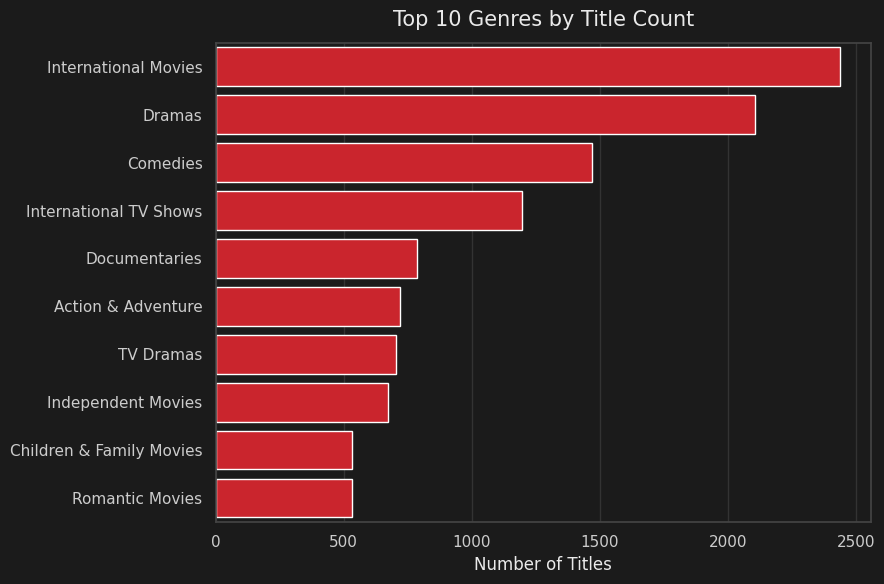

In [7]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

fig, ax = plt.subplots(figsize=(9,6))
sns.barplot(x=top_genres.values, y=top_genres.index, ax=ax, color='#E50914')
ax.set_title('Top 10 Genres by Title Count', fontsize=15, color='#eaeaea', pad=12)
ax.set_xlabel('Number of Titles')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 5. Content Additions Over Time

How many titles were added to Netflix each year.

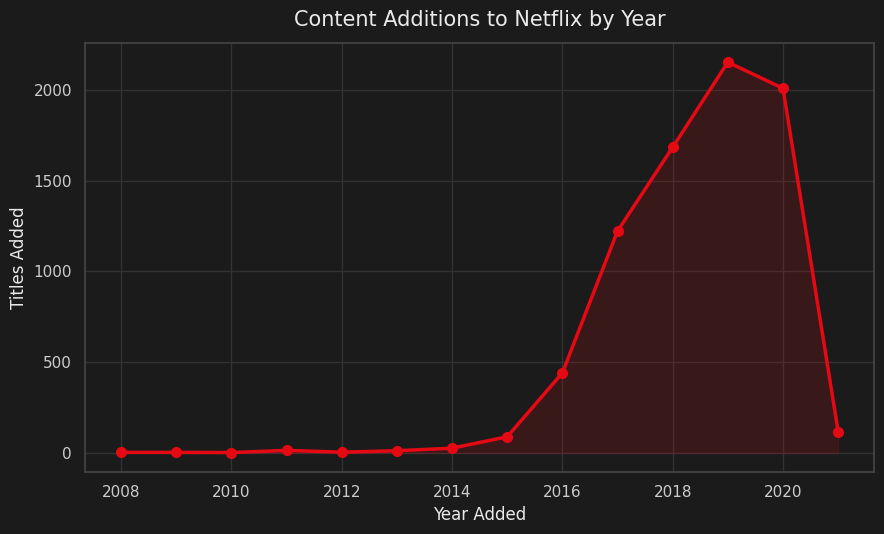

In [8]:
by_year = df[df['year_added'] <= 2021]['year_added'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9,5.5))
ax.plot(by_year.index, by_year.values, marker='o', color='#E50914', linewidth=2.5, markersize=7)
ax.fill_between(by_year.index, by_year.values, alpha=0.15, color='#E50914')
ax.set_title('Content Additions to Netflix by Year', fontsize=15, color='#eaeaea', pad=12)
ax.set_xlabel('Year Added')
ax.set_ylabel('Titles Added')
plt.tight_layout()
plt.show()

## 6. Top Content-Producing Countries

`country` can also hold multiple comma-separated values, so we explode it the same way as genres.

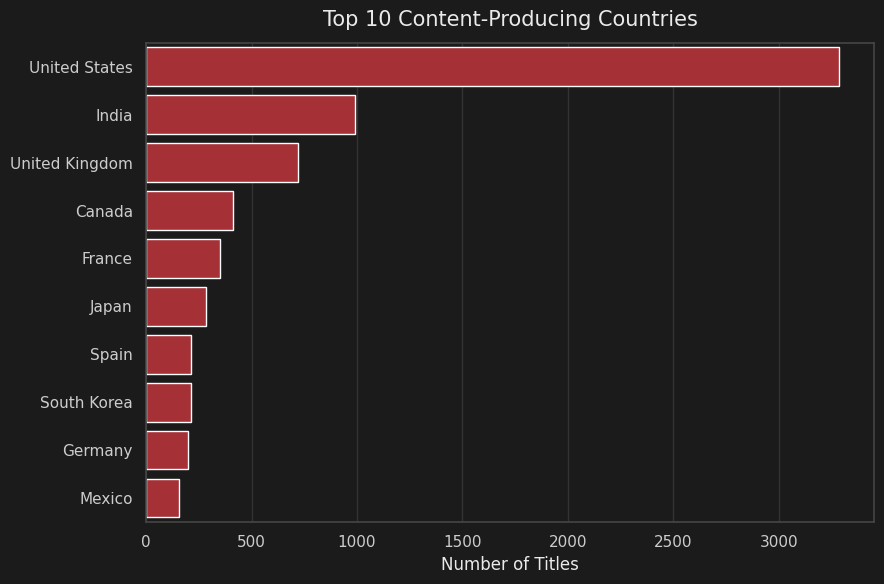

In [9]:
countries = df['country'].str.split(', ').explode()
countries = countries[countries != 'Unknown']
top_countries = countries.value_counts().head(10)

fig, ax = plt.subplots(figsize=(9,6))
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, color='#B81D24')
ax.set_title('Top 10 Content-Producing Countries', fontsize=15, color='#eaeaea', pad=12)
ax.set_xlabel('Number of Titles')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 7. Content Ratings Distribution

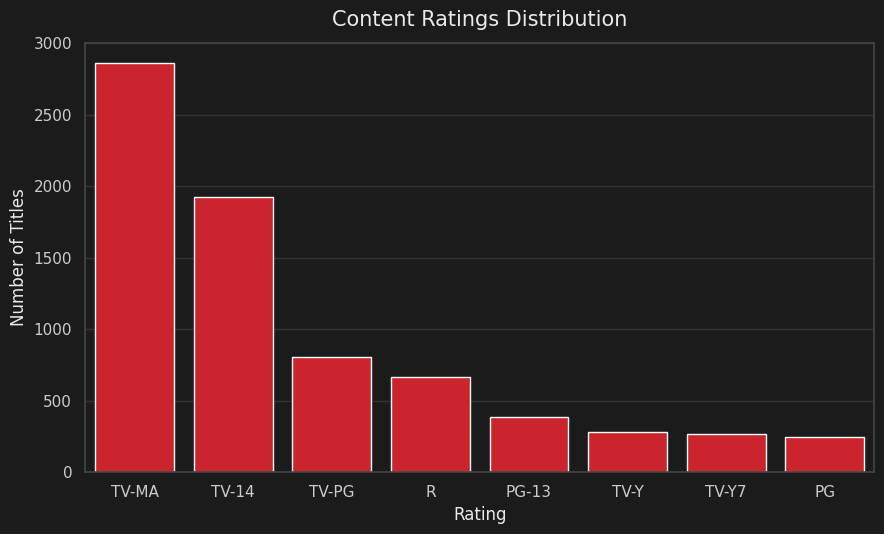

In [10]:
top_ratings = df['rating'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(9,5.5))
sns.barplot(x=top_ratings.index, y=top_ratings.values, ax=ax, color='#E50914')
ax.set_title('Content Ratings Distribution', fontsize=15, color='#eaeaea', pad=12)
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Titles')
plt.tight_layout()
plt.show()

## 8. Movie Duration Distribution

Average movie duration: 99.3 minutes


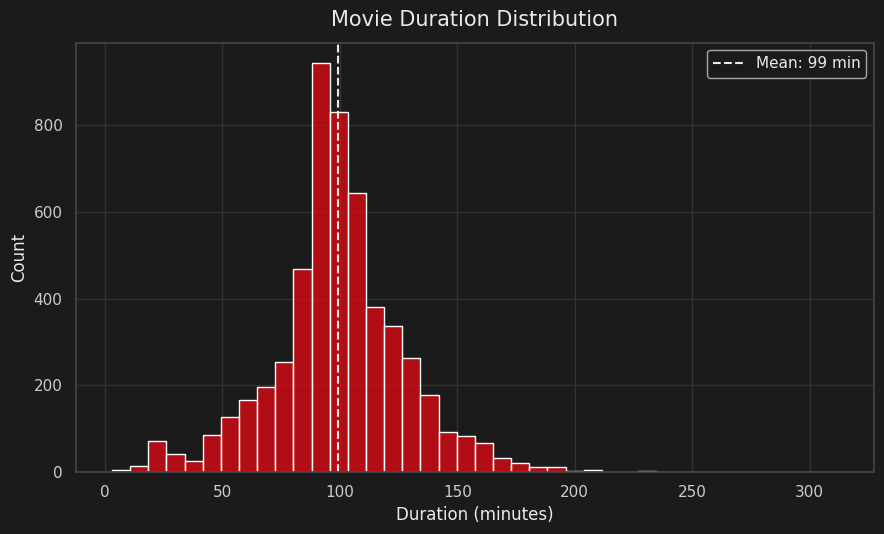

In [11]:
movies = df[df['type']=='Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min','', regex=False)
movies = movies[movies['duration_min'].str.isnumeric()]
movies['duration_min'] = movies['duration_min'].astype(int)
avg_duration = movies['duration_min'].mean()
print(f"Average movie duration: {avg_duration:.1f} minutes")

fig, ax = plt.subplots(figsize=(9,5.5))
sns.histplot(movies['duration_min'], bins=40, color='#E50914', ax=ax)
ax.axvline(avg_duration, color='#eaeaea', linestyle='--', linewidth=1.5, label=f'Mean: {avg_duration:.0f} min')
ax.set_title('Movie Duration Distribution', fontsize=15, color='#eaeaea', pad=12)
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Key Findings

- Movies make up **69.1%** of the catalog vs. **30.9%** TV Shows.
- **International Movies**, **Dramas**, and **Comedies** are the most common genres.
- Content additions peaked in **2019** (2,153 titles added) before declining sharply in 2020-2021.
- The **United States** (3,287 titles) and **India** (990 titles) are the top two content-producing countries by a wide margin.
- **TV-MA** and **TV-14** are the most common content ratings, together covering more than half the catalog.
- Average movie duration is approximately **99 minutes**.